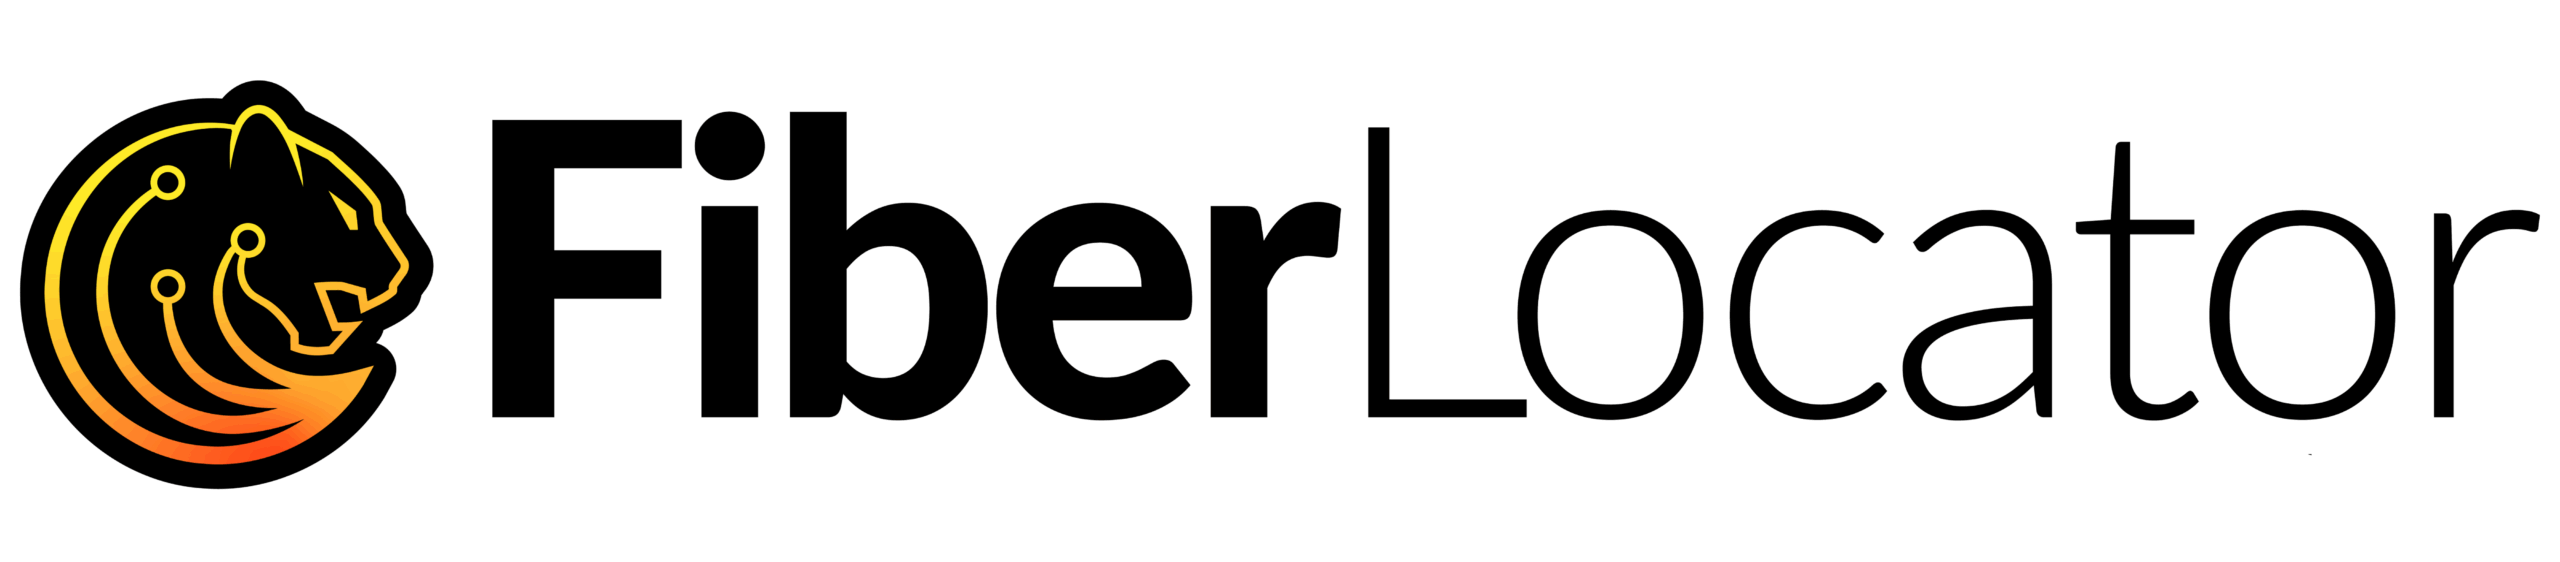

# FiberLocator vs. FCC BDC Data
Updated: 2026-03-20  
Mike Iapaucci- Karen Pesca  
Vice President, CCMI  
miapalucci@ccmi.com  
env: gis

In [ ]:
import sys

# Install required libraries
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install folium
!{sys.executable} -m pip install geojson
!{sys.executable} -m pip install h3
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install shapely
!{sys.executable} -m pip install geopandas
!{sys.executable} -m pip install session_info

In [ ]:
import csv
import folium
import h3
import json
import math
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
pp = pprint.PrettyPrinter(indent=4)
import requests
import shapely.geometry as geometry

import geopandas as gpd
from geojson import Polygon, Feature, FeatureCollection, dump
from folium import features
from PIL import Image

In [ ]:
import os
os.environ['CONDA_DEFAULT_ENV']

In [ ]:
import session_info
session_info.show()

## Step 1: Download data from FCC BDC  
https://broadbandmap.fcc.gov/data-download

In [ ]:
#Option 1: Check your current working directory
#print("Current working directory:", os.getcwd())


In [ ]:
# Fiber
tx_fiber = pd.read_csv("bdc_48_FibertothePremises_fixed_broadband_J25_03mar2026.csv")
tx_fiber.head()

In [ ]:
#Number of observations fiber premises
len (tx_fiber)

In [ ]:
#cable texas
tx_cable = pd.read_csv("bdc_48_Cable_fixed_broadband_J25_03mar2026.csv")
tx_cable.head()

In [ ]:
#number of observations cable
len(tx_cable)

In [ ]:
# Combine fiber and cable into one dataframe TEXAS
tx_fiber_cable = pd.concat([tx_fiber, tx_cable])
tx_fiber_cable.value_counts("technology").sort_values()

In [ ]:
#Shaped of te combined dataset
import numpy as np
print(tx_fiber_cable.shape)


## Step 2: Filter data for counties of interest and business clients Odessa
Cities: Odessa TX (Ector County= 48135, Midland County= 48329)

In [ ]:
tx_fiber_cable_4 = tx_fiber_cable[tx_fiber_cable["block_geoid"].apply(lambda x: str(x)[:5] in ["48135","48329"])]

In [ ]:
print("All of Texas: ", tx_fiber_cable.shape[0])
print("Odessa: ", tx_fiber_cable_4.shape[0])

In [ ]:
tx_fiber_cable_4.value_counts("business_residential_code")

In [ ]:
# Remove the solely residential buildings (code=R)
tx_fiber_cable_4 = tx_fiber_cable_4[tx_fiber_cable_4["business_residential_code"] != "R"]
tx_fiber_cable_4.value_counts("business_residential_code")

In [ ]:
# Change codes to proper names
tx_fiber_cable_4["business_code_name"] = tx_fiber_cable_4["business_residential_code"].apply(lambda x: "Biz/Res" if x =="X" \
else "Biz")
tx_fiber_cable_4["technology_name"] = tx_fiber_cable_4["technology"].apply(lambda x: "Fiber" if x == 50 else "Cable")

In [ ]:
pd.crosstab(tx_fiber_cable_4["technology_name"], tx_fiber_cable_4["business_code_name"], margins=True, margins_name="Total")

## Step 3: Create summary data for use as attribute data

In [ ]:
tx_fiber_cable_4.value_counts("brand_name").sort_values(ascending=False)

### Create Bar charts for brand_name as my 1st visualization

In [ ]:
# Count brands
brand_counts = tx_fiber_cable_4["brand_name"].value_counts()

# Take top 10
top_brands = brand_counts.head(10)

In [ ]:
#Bart chat

brand_counts = tx_fiber_cable_4["brand_name"].value_counts()
top_brands = brand_counts.head(10)

# color palette
colors = plt.cm.tab10(np.linspace(0, 1, len(top_brands)))

plt.figure(figsize=(12, 6))

top_brands.sort_values().plot(kind='barh', color=colors)

plt.title("Top 10 Broadband Providers in Odessa TX (FCC Data)")
plt.xlabel("Number of Locations")
plt.ylabel("Provider")

# labels
for index, value in enumerate(top_brands.sort_values()):
    plt.text(value, index, f" {value}", va='center')

plt.tight_layout()
plt.show()

In [ ]:
#continue mike's analysis

In [ ]:
tx_fiber_cable_4.head()

In [ ]:
# Potential for multiple providers in any given h3 hexagon.  Here the first hex in the list has 3 providers with a total of
# 2354 locations.
hex_1tx = tx_fiber_cable_4[["brand_name", "h3_res8_id"]][tx_fiber_cable_4["h3_res8_id"] == "8848d6d95dfffff"]
print(hex_1tx.value_counts("brand_name"))
print("Total locations in hex 1: ", len(hex_1tx["h3_res8_id"]))

In [ ]:
#tx_fiber_cable_4["h3_res8_id"].value_counts().head(10) # revuse is not in the same place as mike

In [ ]:
hex_1tx.columns

In [ ]:
print(tx_fiber_cable_4.columns.tolist())

In [ ]:
tx_attributes = tx_fiber_cable_4[["brand_name", "location_id", "h3_res8_id", "technology_name",\
                                "business_code_name"]].groupby(by=['h3_res8_id']).agg(lambda x: list(x))
tx_attributes.head()

In [ ]:
# Create unique counts of brand_name, location_id, technology_name, and business_code_name for each h3 hexagon.
tx_attributes["unique_brands"] = tx_attributes["brand_name"].apply(lambda x: list(set(x)))
tx_attributes["unique_brands_count"] = tx_attributes["unique_brands"].apply(lambda x: len(x))
tx_attributes["locations"] = tx_attributes["location_id"].apply(lambda x: len(x))
tx_attributes["technologies"] = tx_attributes["technology_name"].apply(lambda x: list(set(x)))
tx_attributes["biz_vs_biz/res"] = tx_attributes["business_code_name"].apply(lambda x: list(set(x)))

In [ ]:
tx_attributes.head()

In [ ]:
hex_provider_counttx = tx_attributes['unique_brands_count'].value_counts().sort_values(ascending=False)
print(hex_provider_counttx)
print("Total hexagons: ", np.sum(hex_provider_counttx))

## Step 4: Create H3 hexagon geometry and key attributes in GeoJSON for mapping

In [ ]:
#print(tx_attributes.columns.tolist()) ## karen

In [ ]:
from shapely.geometry import Polygon

def add_geometry(row):
    boundary = h3.cell_to_boundary(row["h3_res8_id"])  # returns (lat, lng)
    points = [(lng, lat) for lat, lng in boundary]     # convert to (lng, lat)
    return Polygon(points)

In [ ]:
tx_attributes = tx_attributes.reset_index()

In [ ]:
tx_attributes.head()

In [ ]:
tx_attributes['geometry'] = (tx_attributes.apply(add_geometry, axis=1))

In [ ]:
tx_attributes.iloc[0]

In [ ]:
tx_attributes = tx_attributes[["h3_res8_id", "location_id", "unique_brands", "unique_brands_count", "locations",
                              "technologies", "biz_vs_biz/res", "geometry"]]
tx_attributes["location_id"] = tx_attributes["location_id"].astype(str)
tx_attributes["unique_brands"] = tx_attributes["unique_brands"].astype(str)
tx_attributes["technologies"] = tx_attributes["technologies"].astype(str)
tx_attributes["biz_vs_biz/res"] = tx_attributes["biz_vs_biz/res"].astype(str)
tx_attributes.head()

In [ ]:
tx_geojson = gpd.GeoDataFrame(tx_attributes)

In [ ]:
def hexagons_dataframe_to_geojson(df_hex, hex_id_field, geometry_field, value_field, file_output = None):

    list_features = []

    for i, row in df_hex.iterrows():
        feature = Feature(geometry = row[geometry_field],
                          id = row[hex_id_field],
                          properties = {"value": row[value_field]})
        list_features.append(feature)

    feat_collection = FeatureCollection(list_features)

    if file_output is not None:
        with open(file_output, "w") as f:
            json.dump(feat_collection, f)

    else :
      return feat_collection

In [ ]:
tx_geojson.head()

In [ ]:
tx_geojson.to_file("tx_bdc.geojson", driver="GeoJSON")

## Step 5: Mapping the data

In [ ]:
import geojson
with open("tx_Counties.geojson") as f:
    counties = geojson.load(f)

In [ ]:
lat = 31.8457
lon = -102.3676
zoom_start = 10

m = folium.Map(location=[lat, lon], zoom_start=zoom_start)

geojson_data = counties
folium.GeoJson(geojson_data,
               name="County Boundaries",
               style_function=lambda feature:{"fillColor": "#85C1E9",
                                             "color": "black",
                                             "weight": 5,
                                             "dashArray": "5, 5",}
              ).add_to(m)

bdc = folium.GeoJson(
    'tx_bdc.geojson',
    name = 'FCC BDC Data',
    show=False,
).add_to(m)

folium.LayerControl(position="bottomright", collapsed=False).add_to(m)

m

In [ ]:
import geojson
with open("tx_bdc.geojson") as f:
    tx_bdc = geojson.load(f)

In [ ]:
# Odessa center
#odessa_lat = 31.8457
#odessa_lon = -102.3676



In [ ]:
tx_bdc['features'][0]

In [ ]:
zoom_start = 10

m = folium.Map(location=[lat, lon],
               zoom_start=zoom_start)

geojson_data = counties
folium.GeoJson(geojson_data,
               name="County Boundaries",
               style_function=lambda feature:{"fillColor": "#85C1E9",
                                             "color": "black",
                                             "weight": 2,
                                             "dashArray": "5, 5",}
              ).add_to(m)

choropleth = folium.Choropleth(
    geo_data = tx_bdc,
    name = 'FCC BDC Data',
    data = tx_geojson,
    columns = ['h3_res8_id', 'locations'],
    key_on = 'feature.properties.h3_res8_id',
    fill_color = 'YlGn',
    fill_opacity = 0.7,
    #line_color = 'Black',
    line_opaciy = 0.1,
    legend_name = 'Number of BSLs Served',
    highlight = True,
).add_to(m)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(['locations', 'biz_vs_biz/res', 'unique_brands'], labels=True)
)

folium.LayerControl(position="bottomright", collapsed=False).add_to(m)

m

## Step 6: Add FiberLocator data to the map

In [ ]:
url = 'https://app.fiberlocator.com/rest/'

In [ ]:
creds = {'login': '', 'password': ''} # confidential information

In [ ]:
endpoint = f'{url}login'
r = requests.post(endpoint, data = creds)
cookies = r.cookies
print(endpoint)
print(r)

In [ ]:
endpoint = f'{url}/token'
get_token = requests.get(endpoint, cookies=r.cookies)
token = get_token.json()['result']['token']

In [ ]:
zoom_start = 10

m = folium.Map(location=[lat, lon],
               zoom_start=zoom_start,
               )

geojson_data = counties
folium.GeoJson(geojson_data,
               name="County Boundaries",
               style_function=lambda feature:{"fillColor": "#85C1E9",
                                             "color": "black",
                                             "weight": 2,
                                             "dashArray": "5, 5",},
               ).add_to(m)

choropleth = folium.Choropleth(
    geo_data = tx_bdc,
    name = 'FCC BDC Data',
    data = tx_geojson,
    columns = ['h3_res8_id', 'locations'],
    key_on = 'feature.properties.h3_res8_id',
    fill_color = 'YlGn',
    fill_opacity = 0.4,
    #line_color = 'Black',
    line_opacity = 0.1,
    legend_name = 'BDC Data',
    highlight = True,
    overlay=True,
    show=True,
).add_to(m)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(['locations', 'unique_brands'], labels=True)
)

fg=folium.FeatureGroup(name='Metro Networks', show=True)

folium.raster_layers.WmsTileLayer(url = f'{url}{token}'+ '/maps/wmts/metro/webmercator/{z}/{x}/{y}.png',
                                  layers='metro',
                                  min_zoom=zoom_start,
                                  fmt='image/png',
                                  attr='<a href=https://www.fiberlocator.com>| FiberLocator</a>',
                                  transparent=True,
                                  overlay=True,
                                  ).add_to(fg)
m.add_child(fg)

fg=folium.FeatureGroup(name='Long Haul Networks', show=True)

folium.raster_layers.WmsTileLayer(url = f'{url}{token}'+ '/maps/wmts/longhaul/webmercator/{z}/{x}/{y}.png',
                                  layers='longhaul',
                                  min_zoom=zoom_start,
                                  fmt='image/png',
                                  attr='<a href=https://www.fiberlocator.com>| FiberLocator</a>',
                                  transparent=True,
                                  overlay=True,
                                  ).add_to(fg)
m.add_child(fg)

fg=folium.FeatureGroup(name='Connected Buidlings', show=True)

folium.raster_layers.WmsTileLayer(url = f'{url}{token}'+ '/maps/wmts/lit_bldgs/webmercator/{z}/{x}/{y}.png',
                                  layers='longhaul',
                                  min_zoom=zoom_start,
                                  fmt='image/png',
                                  attr='<a href=https://www.fiberlocator.com>| FiberLocator</a>',
                                  transparent=True,
                                  overlay=True,
                                  ).add_to(fg)
m.add_child(fg)

folium.LayerControl(position="bottomright", collapsed=False).add_to(m)

m
 


In [ ]:
m.save("Odessa_TX_Broadband.html")

## Step 7: Compare FiberLocator providers to BDC providers

In [ ]:
# Minimum bounding box incorporating the 2 counties

# Odessa / Midland study area bbox
# Format: [west, south, east, north]
bbox = [-102.83, 31.55, -101.75, 32.15]

In [ ]:
zoom_start = 9


m = folium.Map(location=[lat, lon],
               zoom_start=zoom_start)

geojson_data = counties
folium.GeoJson(geojson_data,
               name="County Boundaries",
               style_function=lambda feature:{"fillColor": "#85C1E9",
                                             "color": "black",
                                             "weight": 2,
                                             "dashArray": "5, 5",}
              ).add_to(m)

kw = {
    "color": "red",
    "fill": False,
    "weight": 5,
    "popup": "Minimum Bounding Box",
}
folium.Rectangle(
    # lat, lon
    bounds=[[bbox[1], bbox[0]], [bbox[3], bbox[2]]],
    line_join="miter",
    #dash_array="5,10",
    **kw,
).add_to(m)

#folium.LayerControl(position="bottomright", collapsed=False).add_to(m)

m



In [ ]:
# Access all providers from FiberLocator within the bounding box.
# lon, lat

endpoint = f'{url}{token}/layers/inview/{bbox[0]},{bbox[1]},{bbox[2]},{bbox[3]}/longhaul,metro,buildings,'
layers_inview = requests.get(endpoint)
pp.pprint(layers_inview.json())

In [ ]:
FLO_Layers = pd.DataFrame(layers_inview.json()["result"], columns=["layer_name"])
FLO_Layers_Unique = pd.DataFrame(FLO_Layers["layer_name"].unique(), columns=["layer_name"]).sort_values("layer_name")
print("Unique Layers: ", len(FLO_Layers_Unique))
FLO_Layers_Unique

In [ ]:
FLO_Layers_Unique.to_csv("FLO_Layers_Unique.csv", index=False)

In [ ]:
BDC_Providers_Unique = pd.DataFrame(tx_fiber_cable_4["brand_name"].unique(), columns=["brand_name"]).sort_values("brand_name")
print("Unique Providers: ", len(BDC_Providers_Unique))
BDC_Providers_Unique

In [ ]:
tx_fiber_cable_4["brand_name"].unique()

In [ ]:
tx_fiber_cable_4[tx_fiber_cable_4["brand_name"] == "Wes-Tex Telecommunications Ltd"].head()

In [ ]:
tx_fiber_cable_4[tx_fiber_cable_4["brand_name"] == "AT&T"].head()

In [ ]:
tx_fiber_cable_4[tx_fiber_cable_4["brand_name"] == "Fusion"].head()

In [ ]:
# Summary of BDC providers in the Odessa/Midland study area

bdc_provider_summary = (
    tx_fiber_cable_4
    .groupby("brand_name")
    .agg(
        total_locations=("location_id", "count"),
        technologies=("technology_name", lambda x: ", ".join(sorted(x.unique()))),
        max_download=("max_advertised_download_speed", "max"),
        max_upload=("max_advertised_upload_speed", "max")
    )
    .reset_index()
    .sort_values("total_locations", ascending=False)
)

bdc_provider_summary

In [ ]:
comparison_table = pd.DataFrame({
    "BDC Providers": sorted(bdc_provider_summary["brand_name"].unique()),
})

comparison_table

In [ ]:
# Clean FiberLocator layer names into possible carrier names
fl_compare = FLO_Layers_Unique.copy()

fl_compare["layer_type"] = fl_compare["layer_name"].str.extract(r"^(lit_buildings|metro|longhaul|data_centers|central_offices)")
fl_compare["fiberlocator_carrier"] = (
    fl_compare["layer_name"]
    .str.replace("lit_buildings_", "", regex=False)
    .str.replace("metro_", "", regex=False)
    .str.replace("longhaul_", "", regex=False)
    .str.replace("_", " ")
    .str.title()
)

fl_summary = (
    fl_compare
    .groupby("fiberlocator_carrier")
    .agg(
        fiberlocator_layer_count=("layer_name", "count"),
        fiberlocator_layer_types=("layer_type", lambda x: ", ".join(sorted(set(x.dropna())))),
        fiberlocator_layers=("layer_name", lambda x: ", ".join(sorted(x)))
    )
    .reset_index()
)

fl_summary.head()

In [ ]:
## Provider Comparison: FCC VS FiberLocator Data

In [ ]:
# Normalize names for comparison
bdc_compare = bdc_provider_summary.copy()
bdc_compare["match_name"] = bdc_compare["brand_name"].str.lower().str.replace(" ", "_")

fl_summary["match_name"] = fl_summary["fiberlocator_carrier"].str.lower().str.replace(" ", "_")

provider_comparison = bdc_compare.merge(
    fl_summary,
    on="match_name",
    how="outer"
)

provider_comparison["In_BDC"] = provider_comparison["brand_name"].notna().map({True: "Yes", False: "No"})
provider_comparison["In_FiberLocator"] = provider_comparison["fiberlocator_carrier"].notna().map({True: "Yes", False: "No"})

provider_comparison = provider_comparison[
    [
        "brand_name",
        "fiberlocator_carrier",
        "In_BDC",
        "In_FiberLocator",
        "total_locations",
        "technologies",
        "fiberlocator_layer_count",
        "fiberlocator_layer_types"
    ]
].sort_values(["In_BDC", "In_FiberLocator"], ascending=False)

provider_comparison